In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [4]:
import pandas as pd
import joblib

# Load datasets
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

# Load models
rf_model = joblib.load("../models/random_forest.pkl")
lgbm_model = joblib.load("../models/lightgbm.pkl")

In [5]:
import pandas as pd

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

In [6]:
rf_model = joblib.load("../models/random_forest.pkl")

lgbm_model = joblib.load("../models/lightgbm.pkl")

In [7]:
X_test = pd.read_csv("../data/X_test.csv")

y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [8]:
rf_pred = rf_model.predict(X_test)

lgbm_pred = lgbm_model.predict(X_test)

In [9]:
print("Random Forest")

print(classification_report(y_test, rf_pred))

print("="*80)

print("LightGBM")

print(classification_report(y_test, lgbm_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.77      0.79       284
           1       0.59      0.38      0.47       159
           2       0.80      0.94      0.87       442

    accuracy                           0.78       885
   macro avg       0.74      0.70      0.71       885
weighted avg       0.77      0.78      0.77       885

LightGBM
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       284
           1       0.55      0.48      0.51       159
           2       0.82      0.90      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.71      0.72       885
weighted avg       0.77      0.78      0.77       885



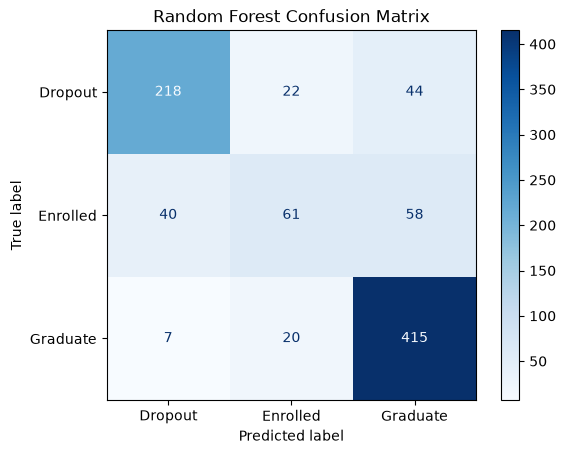

In [10]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dropout","Enrolled","Graduate"]
)

disp.plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

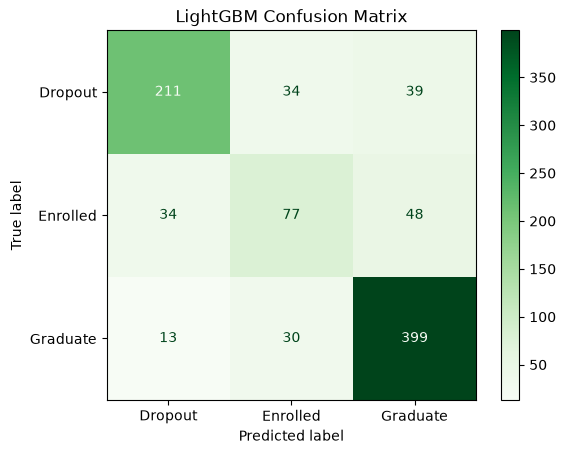

In [11]:
cm = confusion_matrix(y_test, lgbm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Dropout","Enrolled","Graduate"]
)

disp.plot(cmap="Greens")

plt.title("LightGBM Confusion Matrix")

plt.show()

In [12]:
rf_prob = rf_model.predict_proba(X_test)

lgbm_prob = lgbm_model.predict_proba(X_test)

In [13]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

In [14]:
rf_auc = roc_auc_score(
    y_test_bin,
    rf_prob,
    multi_class="ovr"
)

lgbm_auc = roc_auc_score(
    y_test_bin,
    lgbm_prob,
    multi_class="ovr"
)

print("Random Forest ROC AUC:", rf_auc)

print("LightGBM ROC AUC:", lgbm_auc)

Random Forest ROC AUC: 0.8917610610912102
LightGBM ROC AUC: 0.8874583854181525


In [15]:
rf_importance = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":rf_model.feature_importances_

})

rf_importance = rf_importance.sort_values(

    by="Importance",

    ascending=False

)

rf_importance.head(15)

,Feature,Importance
40,Approval_rate,0.132737
37,Total_approved,0.082034
30,Curricular units 2nd sem (approved),0.071335
31,Curricular units 2nd sem (grade),0.056719
36,Average_grade,0.054582
24,Curricular units 1st sem (approved),0.046925
25,Curricular units 1st sem (grade),0.039377
12,Admission grade,0.036105
19,Age at enrollment,0.034165
6,Previous qualification (grade),0.031699


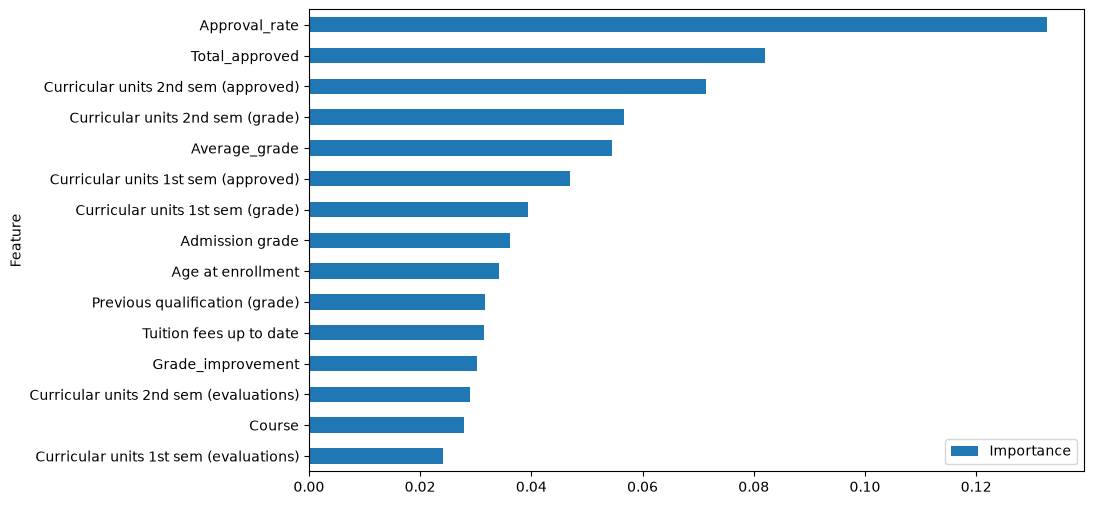

In [16]:
rf_importance.head(15).plot(

    x="Feature",

    y="Importance",

    kind="barh",

    figsize=(10,6)

)

plt.gca().invert_yaxis()

plt.show()

## **SHAP Explainability**

In [17]:
import numpy as np
import sys

print(np.__version__)
print(sys.executable)

2.3.3
c:\Users\gubba\OneDrive\Desktop\student-dropout-risk\venv\Scripts\python.exe


In [18]:
import sys
import numpy as np

print("Python executable:", sys.executable)
print("NumPy version:", np.__version__)

Python executable: c:\Users\gubba\OneDrive\Desktop\student-dropout-risk\venv\Scripts\python.exe
NumPy version: 2.3.3


In [19]:
import numpy as np
print(np.__version__)

2.3.3


In [20]:
import shap

In [21]:
explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_test)

JSONDecodeError: Invalid control character at: line 9 column 110 (char 285)

In [ ]:
import lightgbm
import shap

print("LightGBM:", lightgbm.__version__)
print("SHAP:", shap.__version__)

LightGBM: 4.7.0
SHAP: 0.52.0


In [ ]:
import re

def clean_columns(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

X_train = clean_columns(X_train)
X_test = clean_columns(X_test)

In [ ]:
explainer = shap.Explainer(lgbm_model)

shap_values = explainer(X_test)

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: LGBMClassifier(random_state=42)

In [ ]:
explainer = shap.Explainer(lgbm_model, X_train)

shap_values = explainer(X_test)

Background dataset has 3539 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3539 when initializing the masker.


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: LGBMClassifier(random_state=42)

In [ ]:
import sys
import lightgbm
import shap
import numpy

print(sys.version)
print(lightgbm.__version__)
print(shap.__version__)
print(numpy.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
4.5.0
0.48.0
2.3.3


In [ ]:
import shap

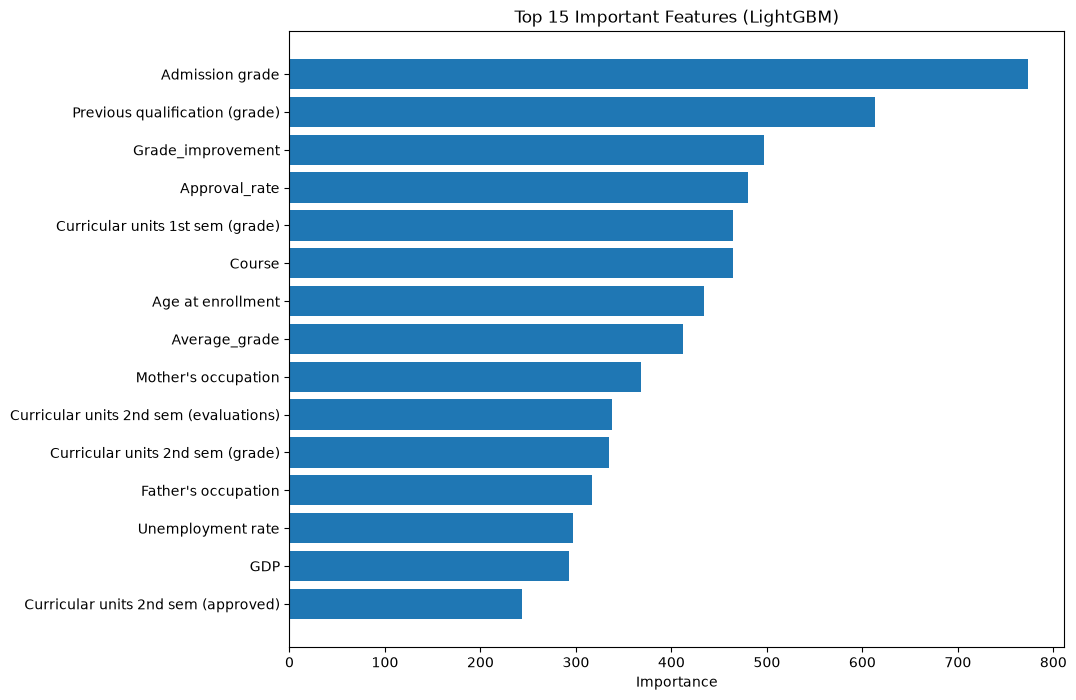

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
plt.barh(importance["Feature"][:15], importance["Importance"][:15])
plt.xlabel("Importance")
plt.title("Top 15 Important Features (LightGBM)")
plt.gca().invert_yaxis()
plt.show()